In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
word_embeddings={
    'cat':[0.8,0.6],
    'kitten':[0.75,0.65],
    'dog':[0.7,0.3],
    'puppy':[0.65,0.35],
    'car':[-0.5,0.2],
    'truck':[-0.45,0.15]
}

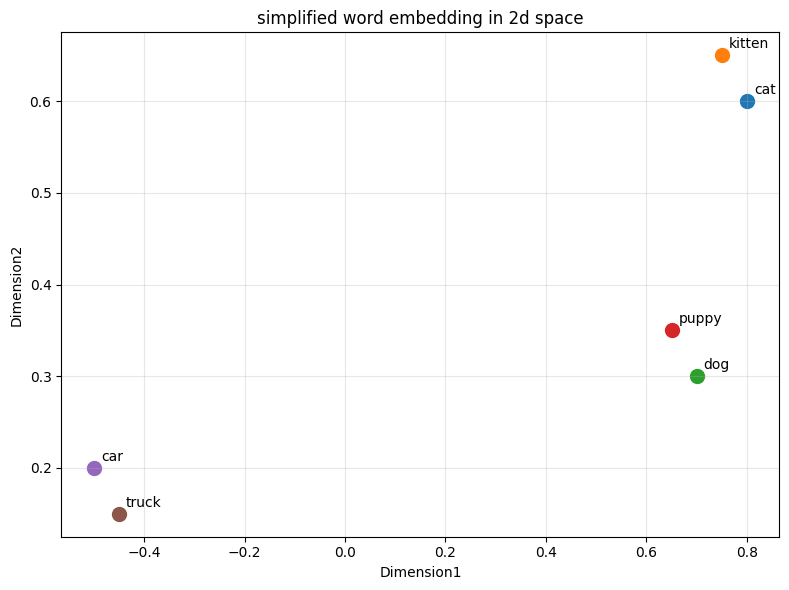

In [4]:
fig,ax=plt.subplots(figsize=(8,6))

for word,coords in word_embeddings.items():
    ax.scatter(coords[0],coords[1],s=100)
    ax.annotate(word,(coords[0],coords[1]),xytext=(5,5),
                textcoords='offset points')

ax.set_xlabel('Dimension1')
ax.set_ylabel('Dimension2')
ax.set_title('simplified word embedding in 2d space')
ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
def cosine_similarity(vec1, vec2):
    '''
    Cosine similarity measures the angle between the two vectors.
     - Result close to 1: vectors are very similar
     - Result close to 0: vectors are orthogonal (no similarity)
     - Result close to -1: vectors are opposite
    '''
    
    dot_product=np.dot(vec1, vec2)
    norm_vec1=np.linalg.norm(vec1)
    norm_vec2=np.linalg.norm(vec2)
    return dot_product/(norm_vec1*norm_vec2)

In [6]:
# eg 
cat_vector=[0.8,0.6,0.3]
kitten_vector=[0.75,0.65,0.35]
car_vector=[-0.5,0.2,0.1]

cat_kitten_sim=cosine_similarity(cat_vector, kitten_vector)
print(cat_kitten_sim)

0.9966186334192181


In [7]:
cosine_similarity(cat_vector, car_vector)

np.float64(-0.43718588548916804)

In [2]:
#Huggingface and openai models 
from langchain_huggingface import HuggingFaceEmbeddings

embeddings=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
embeddings

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 20981.71it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [4]:
## create first embedding 
text='hello i am learning about embedding'
embedding=embeddings.embed_query(text)
print(f'text:{text}')
print(f'embedding length :{len(embedding)}')
print(embedding)


text:hello i am learning about embedding
embedding length :384
[-0.0016409140080213547, -0.07472780346870422, -0.01141324546188116, -0.008305086754262447, 0.024603629484772682, 0.07469876110553741, 0.015992863103747368, 0.018734874203801155, 0.04840190336108208, -0.024379387497901917, 0.023542070761322975, 0.06919597089290619, 0.048959631472826004, -0.005005495622754097, -0.06334784626960754, 0.0174871776252985, 0.055944327265024185, 0.05867812782526016, -0.08954071253538132, -0.029820039868354797, -0.023854101076722145, -0.05732787400484085, -0.003607750404626131, -0.10292921215295792, 0.006383040454238653, -0.017305875197052956, -0.008628327399492264, 0.06156689301133156, 0.1126990020275116, -0.06540341675281525, 0.058751776814460754, -0.05331353843212128, 0.003291717264801264, 0.053540509194135666, -0.0899241641163826, 0.10551508516073227, 0.03253832459449768, -0.018465561792254448, -0.07809524238109589, -0.007356164511293173, 0.012256288900971413, 0.008080217987298965, -0.026695465

In [7]:
sentences=[
    'the cat is on the roof',
    'a dog is in the yard',
    'the car is parked outside',
    'the kitten is playing with a ball'
]

embedding_sentences=embeddings.embed_documents(sentences)

print(f'text:{sentences}')
print(f'embedding length :{len(embedding_sentences)}')
print(embedding_sentences)


text:['the cat is on the roof', 'a dog is in the yard', 'the car is parked outside', 'the kitten is playing with a ball']
embedding length :4
[[0.08521576225757599, 0.07675714790821075, 0.02617848478257656, 0.011285939253866673, -0.041973818093538284, -0.01274387538433075, 0.015188094228506088, 0.023337315768003464, 0.0008854041225276887, 0.025326522067189217, -0.03534342348575592, 0.044662028551101685, 0.008443575352430344, -0.005998674780130386, -0.027547378093004227, 0.005294401664286852, -0.06866482645273209, -0.010484655387699604, 0.04147385433316231, 0.043651048094034195, -0.00318271410651505, -0.03341316431760788, 0.016585977748036385, -0.03718139976263046, -0.04469858109951019, 0.044944725930690765, -0.06127183139324188, -0.02812151052057743, -0.003833495546132326, -0.01407819427549839, -0.016358787193894386, -0.011534278281033039, -0.06685305386781693, 0.05993759632110596, -0.014648673124611378, -0.05992917716503143, 6.406612374121323e-05, -0.040332481265068054, -0.01230117212